# Archetype Re-validation — 2026-04-30

Re-extract the awesome-design-md corpus and compare clusters against the original 54-system K-means partition. See `docs/superpowers/specs/2026-04-30-archetype-revalidation-design.md` for methodology.

In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

DATA = Path("../../../data/extracted.json")
FIGS = Path("../figures/2026-04-30")
FIGS.mkdir(parents=True, exist_ok=True)

ORIGINAL_VARS = ["btn_radius", "card_radius", "heading_weight", "body_line_height",
                 "heading_letter_spacing", "shadow_intensity", "btn_shape"]
COLOR_VARS    = ["brand_l", "brand_c", "brand_h"]
NEW_VARS      = ["dark_mode_present", "gray_chroma", "accent_offset"]
ALL_VARS      = ORIGINAL_VARS + COLOR_VARS + NEW_VARS

In [2]:
records = json.loads(DATA.read_text())
df = pd.DataFrame(records)
print(f"Loaded {len(df)} systems")
print("\nFailure rate per variable:")
for v in ALL_VARS:
    null = df[v].isna().sum()
    print(f"  {v:24s} {null}/{len(df)} ({null/len(df)*100:.1f}%)")
df.head()

Loaded 58 systems

Failure rate per variable:
  btn_radius               1/58 (1.7%)
  card_radius              20/58 (34.5%)
  heading_weight           1/58 (1.7%)
  body_line_height         2/58 (3.4%)
  heading_letter_spacing   4/58 (6.9%)
  shadow_intensity         17/58 (29.3%)
  btn_shape                1/58 (1.7%)
  brand_l                  1/58 (1.7%)
  brand_c                  1/58 (1.7%)
  brand_h                  1/58 (1.7%)
  dark_mode_present        1/58 (1.7%)
  gray_chroma              10/58 (17.2%)
  accent_offset            20/58 (34.5%)


,system,btn_radius,card_radius,heading_weight,body_line_height,heading_letter_spacing,shadow_intensity,btn_shape,brand_l,brand_c,brand_h,dark_mode_present,gray_chroma,accent_offset
0,airbnb,8.0,NaN,700.0,1.50,0.0,NaN,2.0,0.657858,0.230920,17.074452,True,0.000000,284.636366
1,airtable,12.0,NaN,500.0,1.25,0.0,NaN,2.0,0.229856,0.019058,262.111418,True,0.014544,133.909950
2,apple,9999.0,NaN,600.0,1.47,0.0,NaN,3.0,0.521966,0.177090,255.829728,True,0.003805,NaN
3,bmw,0.0,NaN,700.0,1.55,0.0,NaN,0.0,0.538093,0.180367,258.296928,True,0.000000,351.756313
4,cal,8.0,NaN,600.0,1.50,-2.0,NaN,2.0,0.177638,0.000000,0.000000,True,0.023361,259.814529


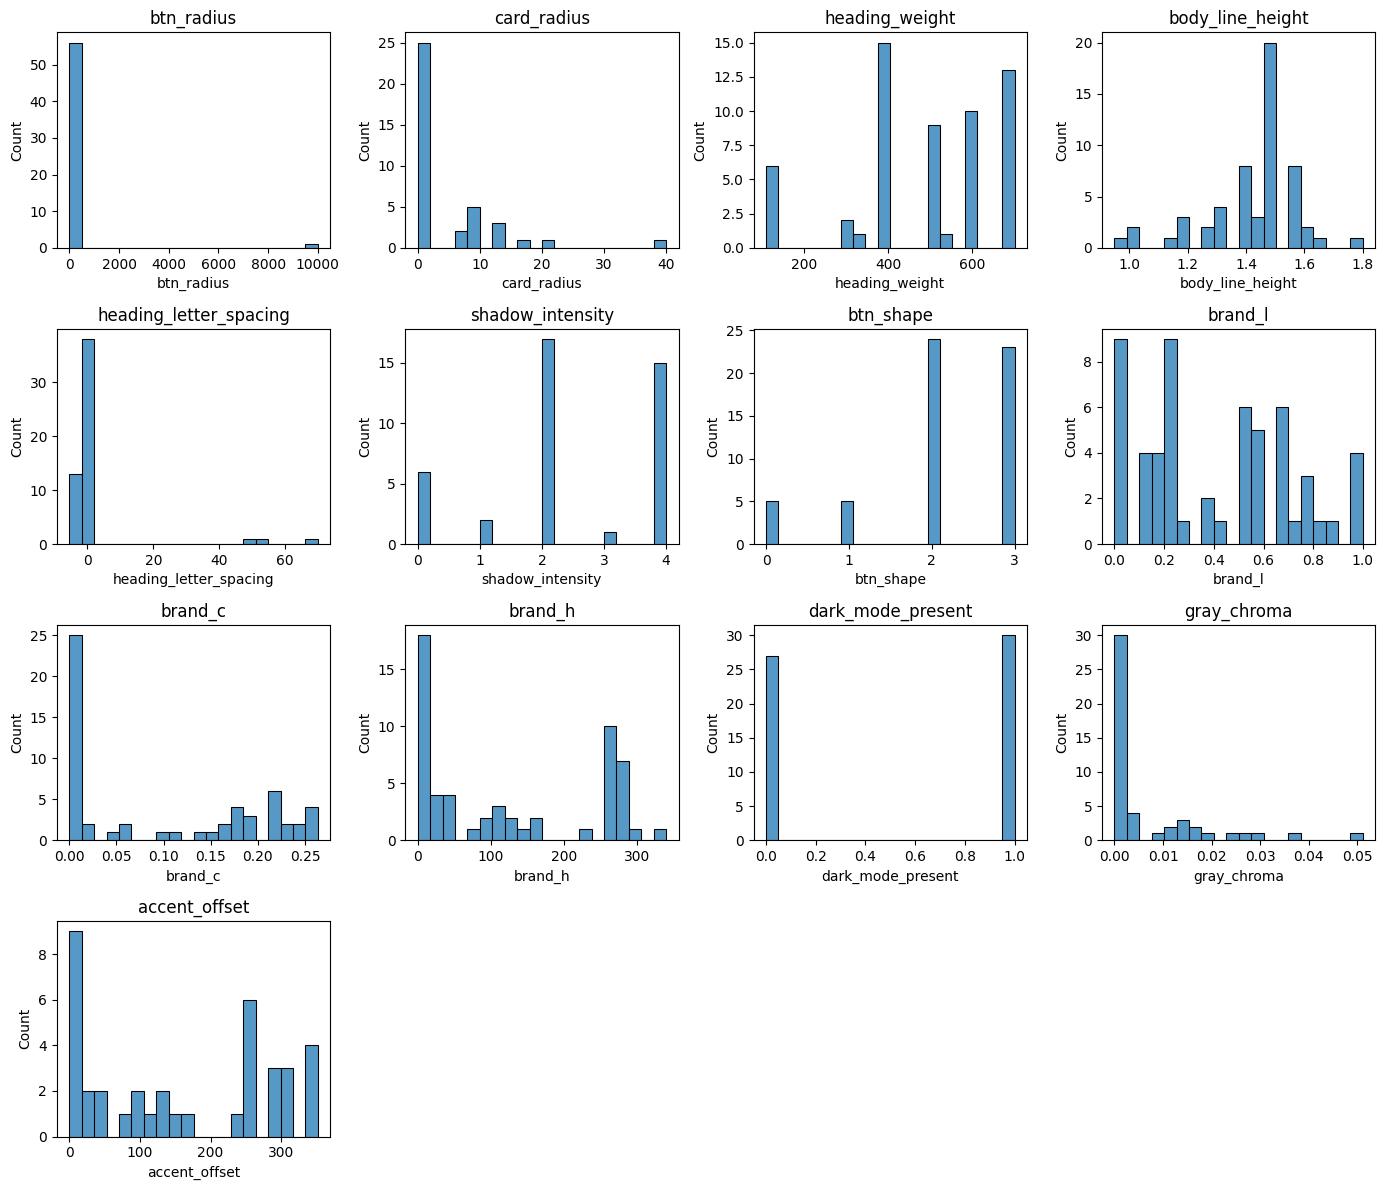

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for ax, v in zip(axes.flat, ALL_VARS):
    s = df[v].dropna()
    if s.dtype == bool:
        sns.countplot(x=s.astype(int), ax=ax)
    else:
        sns.histplot(s, ax=ax, bins=20)
    ax.set_title(v)
for ax in axes.flat[len(ALL_VARS):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGS / "01-univariate.png", dpi=120)
plt.show()

In [4]:
ORIGINAL_CSV = Path("original_54.csv")
orig = pd.read_csv(ORIGINAL_CSV)
X_orig = StandardScaler().fit_transform(orig[ORIGINAL_VARS])
km4_orig = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_orig)
baseline_silhouette = silhouette_score(X_orig, km4_orig.labels_)
print(f"Original (n={len(orig)}, k=4) silhouette: {baseline_silhouette:.3f}")

Original (n=54, k=4) silhouette: 0.275


New corpus complete-case n=35 of 58


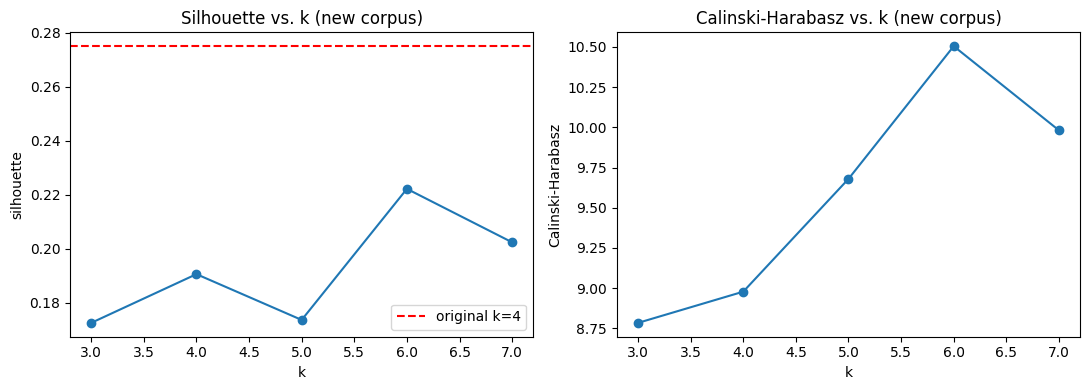

Recommended k = 6 (silhouette=0.222)


In [5]:
new = df[ORIGINAL_VARS].dropna()
print(f"New corpus complete-case n={len(new)} of {len(df)}")
X_new = StandardScaler().fit_transform(new)

ks = list(range(3, 8))
silhouettes, calinskis = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_new)
    silhouettes.append(silhouette_score(X_new, km.labels_))
    calinskis.append(calinski_harabasz_score(X_new, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ks, silhouettes, "o-"); ax1.set_xlabel("k"); ax1.set_ylabel("silhouette")
ax1.axhline(baseline_silhouette, color="red", linestyle="--", label="original k=4")
ax1.legend(); ax1.set_title("Silhouette vs. k (new corpus)")
ax2.plot(ks, calinskis, "o-"); ax2.set_xlabel("k"); ax2.set_ylabel("Calinski-Harabasz")
ax2.set_title("Calinski-Harabasz vs. k (new corpus)")
fig.tight_layout()
fig.savefig(FIGS / "02-cluster-search.png", dpi=120)
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print(f"Recommended k = {best_k} (silhouette={max(silhouettes):.3f})")